# Declare Useful Functions

Functions that are used throughout this notebook are declared here

In [1]:
from BLEanalysis.signals import Signals
import numpy as np

def extract_every_rss_at_angle(ble_signals :Signals, theta :float):
    """
    Examines a given list of signals and returns all the RSS measurements
    taken at a given angle of theta. Leaves ~2s between each
    packet, allowing the transmitter to do a full rotation.
    Adapted from Mike's code in the meeting
    :param ble_signals: A log file parsed as Signals
    :param theta: The angle of rotation to extract RSS measurements, in radians
    :return: A list of RSS measurements
    :rtype: list
    """
    # extract the data, excluding the first 200
    ble_data = ble_signals.data[200:,:] #RSSI, ID, Angle, Time

    # index of the first packet with a gamma of approximately theta
    index_of_packet = np.argmin(np.abs(
        ble_data[(ble_data[:, -1] < ble_data[0, -1] + 201), 2] - theta
    ))

    rss_values = []

    # search through the entire log file until reaching the end
    try:
        while True:
            # range of time values of packets ~2s since the previous one
            search_start_time = ble_data[index_of_packet, 3] + 1750
            search_end_time = ble_data[index_of_packet, 3] + 2250

            # get indexes of packets ~2s since the previous one
            time_index_start = np.argmin(np.abs(ble_data[:,3] - search_start_time))
            time_index_end = np.argmin(np.abs(ble_data[:, 3] - search_end_time))

            # get the packet with the closest angle to theta
            index_of_packet = np.argmin(np.abs(ble_data[time_index_start:time_index_end, 2] - theta)) + time_index_start

            # check if the packet includes the angle we want
            if np.abs(ble_data[index_of_packet, 2] - theta) < 0.1:
                rss_values.append(ble_data[index_of_packet, 0])
    finally:
        #print(f"{len(rss_values)} RSS values found")
        return rss_values


I0000 00:00:1778576942.245161   16592 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778576944.367939   16592 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
import matplotlib.pyplot as plt

def draw_rss_difference_histogram(rss_values :list):
    """
    Draws a histogram of the RSS difference between each RSS measurement
    :param rss_values: The list of RSS measurements
    """
    rss_diffs = []

    for x in range(len(rss_values) - 2):
        rss_diffs.append(rss_values[x] - rss_values[x + 1])

    # plot the histogram
    plt.ylabel("Frequency")
    plt.xlabel("Difference in RSS")
    plt.hist(rss_diffs)


# Draw Graphs of RSS Differences

The first part of the code below will find the differences in RSS between sequential packets for a given angle of theta, allowing ~2s to pass between each packet. This allows the transmitter to do a full rotation between packets, preventing packets taken milliseconds apart with the same RSS from effecting the results.

The second part generates the same graph as above, but for every integer from 0-360 degrees. Note that this takes 34 seconds to run and an extremely long time to render!

In [ ]:
import math

ble_signals = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", ['c', ], angleOffset=0)

# --- plot a graph of RSS difference between packets at a given theta ---
theta = math.radians(0)

plt.title(f"RSS Differences at {math.degrees(theta)} Degrees")

draw_rss_difference_histogram(
    extract_every_rss_at_angle(ble_signals, theta)
)

# Draw Graph Combining RSS Differences for Every Angle

For every angle from 0-360 degrees, finds the difference in the RSS measurement between sequential packets for that angle, and then combines these differences into a single histogram.

In [ ]:
def draw_histogram_for_rss_at_every_angle(ble_signals :Signals, graph_title :str):
    """
    Find the RSS differences for every degree in 360 degrees and compile them into one histogram
    """
    all_rss_diffs = []

    for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
        rss_values = extract_every_rss_at_angle(ble_signals, theta)
        #if theta<2*np.pi-0.2 and theta>0.2: continue
        # get difference between RSSes
        for x in range(5,len(rss_values) - 5):
            all_rss_diffs.append([rss_values[x] - rss_values[x + 5],rss_values[x-5] - rss_values[x]])

    return all_rss_diffs
    plt.hist(all_rss_diffs, bins=np.arange(-20,20))
    plt.title(graph_title)
    plt.ylabel("Frequency")
    plt.xlabel("Difference in RSS")

ble_signals = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log", ['c', ], angleOffset=0)
d = draw_histogram_for_rss_at_every_angle(ble_signals, "RSS Differences Across All Angles")

In [ ]:
d = np.array(d)
plt.hist2d(d[:,0],d[:,1],bins=np.arange(-20,20))

5Same as the above, but for all the log files from the `TreeOcclusionProfiles` experiment.

In [ ]:
filenames = ["treeclose1m.log", "treeinfront.log", "treeocclusion187.log"]

for x in range(len(filenames)):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/Feb 18 2025 Field Trial/TreeOcclusionProfiles/{filenames[x]}", ['c',], angleOffset=0)

    plt.subplot(2, 2, x + 1)
    draw_histogram_for_rss_at_every_angle(ble_signals, filenames[x])

plt.suptitle("RSS Differences in Tree Occlusion Profiles")
plt.tight_layout()
plt.show()

Same as the above, but examining the complex paths within `March 26 2025 Field Trial/complexpath*` folders

In [ ]:
plt.subplots(3, 2, figsize=(20, 20))

for x in range(7, 12):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/complexpath{x}/complexpath{x}.log", ['c',], angleOffset=0)

    plt.subplot(3, 2, x - 6)
    draw_histogram_for_rss_at_every_angle(ble_signals, f"complexpath{x}.log")

plt.suptitle("RSS Differences for Complex Paths")
plt.tight_layout()
plt.show()

Same as the above, but for all of the straight paths in the `March 2 2025 Field Trial/straightpath*` folders

In [ ]:
plt.subplots(3, 2, figsize=(20, 20))

# first three files with a similar naming scheme
for x in range(1, 4):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath{x}/straightpath{x}.log", ['c',], angleOffset=0)

    plt.subplot(3, 2, x)
    draw_histogram_for_rss_at_every_angle(ble_signals, f"simplepath{x}.log")

# last two files with a different naming scheme
for x in range(4, 6):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath{x}/straightpath{x}noperson.log", ['c',], angleOffset=0)

    plt.subplot(3, 2, x)
    draw_histogram_for_rss_at_every_angle(ble_signals, f"simplepath{x}noperson.log")

plt.suptitle("RSS Differences for Simple Paths")
plt.tight_layout()
plt.show()

# Graphs of RSS Differences Between Every Angles Across Multiple Files and Probability Distributions

Does the same as the previous cell, but does this for every file in the `March 26 2025 Field Trial/Range Trials`, `March 26 2025 Field Trial/complexpath*` and `March 26 2025 Field Trial/simplepath*` folders, producing separate histograms for each. A normal distribution is then calculated from these histograms and plotted directly below. The parameters of the NDs are printed after all graphs are plotted.

In [ ]:
from scipy.stats import norm
from scipy.stats import expon

plt.subplots(1, 3, figsize=(15, 5), sharex=True)
means = []
standard_deviations = []

# --- range trials ---
all_rss_diffs = []

# examine all 9 log files
for file_num in range (1, 9):
    print(f"Examining file {file_num}.log")

    # 6.log causes an error
    if file_num == 6:
        continue

    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/{file_num}.log", ['c',], angleOffset=0)

    for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
        rss_values = extract_every_rss_at_angle(ble_signals, theta)

        # get difference between RSSes
        for x in range(len(rss_values) - 2):
            all_rss_diffs.append(rss_values[x] - rss_values[x + 1])

# draw the histogram
plt.subplot(1, 3, 1)
plt.hist(all_rss_diffs, bins=np.arange(-20,20))
plt.title("All Angles in March 2025 Field Trial Range Trials")
plt.ylabel("Frequency")
plt.xlabel("Difference in RSS")

# calculate the normal distribution
means.append(np.mean(all_rss_diffs))
standard_deviations.append(np.std(all_rss_diffs))
print(expon.fit(all_rss_diffs))

# --- Complex paths ---
all_rss_diffs = []

for x in range(7, 12):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/complexpath{x}/complexpath{x}.log", ['c',], angleOffset=0)

    for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
        rss_values = extract_every_rss_at_angle(ble_signals, theta)

        # get difference between RSSes
        for x in range(len(rss_values) - 2):
            all_rss_diffs.append(rss_values[x] - rss_values[x + 1])

# draw the histogram
plt.subplot(1, 3, 2)
plt.hist(all_rss_diffs, bins=np.arange(-20,20))
plt.title("All Angles in Complex Paths")
plt.ylabel("Frequency")
plt.xlabel("Difference in RSS")

# calculate the normal distribution
means.append(np.mean(all_rss_diffs))
standard_deviations.append(np.std(all_rss_diffs))

# --- simple paths ---
all_rss_diffs = []

for x in range(1, 4):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath{x}/straightpath{x}.log", ['c',], angleOffset=0)

    for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
        rss_values = extract_every_rss_at_angle(ble_signals, theta)

        # get difference between RSSes
        for x in range(len(rss_values) - 2):
            all_rss_diffs.append(rss_values[x] - rss_values[x + 1])

# draw the histogram
plt.subplot(1, 3, 3)
plt.hist(all_rss_diffs, bins=np.arange(-20,20))
plt.title("All Angles in Simple Paths")
plt.ylabel("Frequency")
plt.xlabel("Difference in RSS")

# calculate the normal distribution
means.append(np.mean(all_rss_diffs))
standard_deviations.append(np.std(all_rss_diffs))

plt.tight_layout()
plt.show()

# --- draw the normal distributions ---
x_axis = np.arange(-15, 15, 0.01)

plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

plt.subplot(1, 3, 1)
plt.ylabel("Probability")
plt.xlabel("Change in RSS from Previous Packet")
plt.title("Normal Distribution for Range Trials")
plt.plot(x_axis, norm.pdf(x_axis, means[0], math.sqrt(standard_deviations[0])))
# plt.plot(expon.pdf(x_axis, -17.0, 16.995401224700586))

plt.subplot(1, 3, 2)
plt.ylabel("Probability")
plt.xlabel("Change in RSS from Previous Packet")
plt.title("Normal Distribution for Complex Paths")
plt.plot(x_axis, norm.pdf(x_axis, means[1], math.sqrt(standard_deviations[1])))

plt.subplot(1, 3, 3)
plt.ylabel("Probability")
plt.xlabel("Change in RSS from Previous Packet")
plt.title("Normal Distribution for Simple Paths")
plt.plot(x_axis, norm.pdf(x_axis, means[2], math.sqrt(standard_deviations[2])))

plt.tight_layout()
plt.show()

# show the parameters of the NDs
for x in range(len(means)):
    print(f"ND {x + 1}: means = {means[x]:.3g}, standard deviation = {standard_deviations[x]:.3g}")

# Change in Attenuation over a series of packets

In [ ]:
# get rss differences at a given angle
plt.figure(figsize=(15,10))

for theta in np.arange(0.0, 2 * math.pi, math.pi / 2):
    rss_values = extract_every_rss_at_angle(ble_signals, theta)

    plt.subplot(2, 1, 1)
    plt.plot(rss_values)

    rss_diffs = []

    # get difference between RSSes
    for x in range(len(rss_values) - 2):
        rss_diffs.append(rss_values[x] - rss_values[x + 1])

    plt.subplot(2, 1, 2)
    plt.plot(rss_diffs)

plt.show()

## RSS for (almost) all sequential packets

Standardising angles and times (shifting by 0.00 degrees)


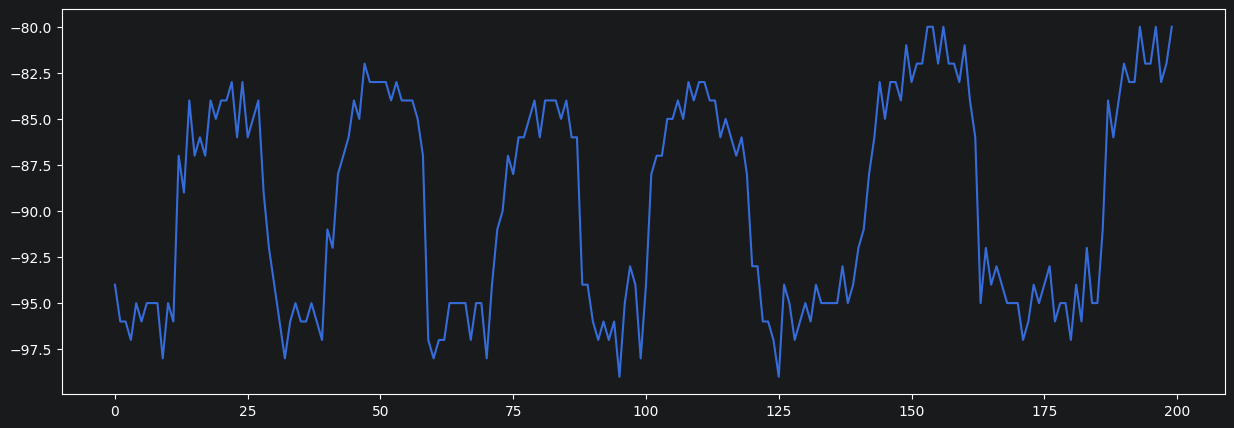

In [23]:
# change over all packets in the file
all_packets = Signals(
    "../../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/5.log", ['c', ], angleOffset=0
    ).data[200:,:] #RSSI, ID, Angle, Time

plt.figure(figsize=(15,5))
plt.plot(all_packets[:200,0])
plt.show()

# Bursts

Using Chris' methods, generate bursts at random points in time and plot their RSS

Standardising angles and times (shifting by 0.00 degrees)


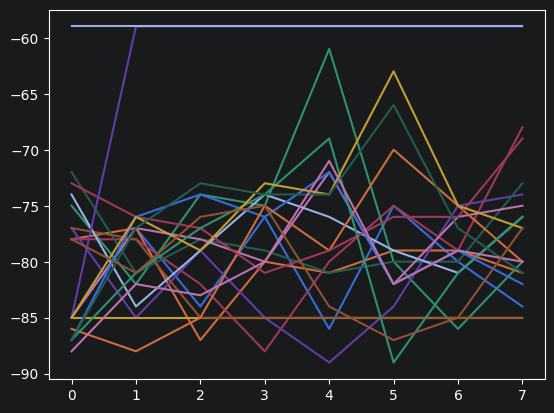

In [24]:
ble_signals = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log", ['c', ], angleOffset=0)

for x in range(20):
    burst_length = 2000
    rsses, _ = ble_signals.getSample(burst_length + 1, burst_length/7)
    plt.plot(rsses)

plt.show()